In [10]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

In [15]:
def pair_trading_strategy(file_voo, file_spy):
    # Load dataset
    os.chdir('C:/Users/eugen/')
    data_voo = pd.read_csv(file_voo)
    data_spy = pd.read_csv(file_spy)

    close_voo = data_voo['close']
    close_spy = data_spy['close']

    # Align indices to ensure all series have the same length
    close_voo, close_spy = close_voo.align(close_spy, join='inner')

    # Calculate the spread (price difference) between VOO and SPY
    spread = close_voo - close_spy

    # Calculate z-score for the spread
    zscore = (spread - spread.mean()) / spread.std()

    # Define entry and exit signals based on z-score thresholds
    entry_zscore = -2
    exit_zscore = 0

    long_signal = (zscore < entry_zscore) & (zscore.shift(1) > entry_zscore)
    short_signal = (zscore > -entry_zscore) & (zscore.shift(1) < -entry_zscore)

    # Initialize variables for backtesting
    initial_capital = 10000  # Initial capital
    cash = initial_capital
    voo_shares = 0
    spy_shares = 0
    total_value = []

    # Prepare to collect trade logs
    trade_logs = []

    for i in range(len(spread)):
        action = 'Hold'
        voo_shares_change = 0
        spy_shares_change = 0
        
        if long_signal[i]:
            action = 'Long VOO & Short SPY'
            voo_shares_to_buy = cash // close_voo.iloc[i]
            spy_shares_to_sell = cash // close_spy.iloc[i]
            cash -= voo_shares_to_buy * close_voo.iloc[i]
            cash += spy_shares_to_sell * close_spy.iloc[i]
            voo_shares += voo_shares_to_buy
            spy_shares -= spy_shares_to_sell
            voo_shares_change = voo_shares_to_buy
            spy_shares_change = -spy_shares_to_sell
        elif short_signal[i]:
            action = 'Short VOO & Long SPY'
            voo_shares_to_sell = cash // close_voo.iloc[i]
            spy_shares_to_buy = cash // close_spy.iloc[i]
            cash += voo_shares_to_sell * close_voo.iloc[i]
            cash -= spy_shares_to_buy * close_spy.iloc[i]
            voo_shares -= voo_shares_to_sell
            spy_shares += spy_shares_to_buy
            voo_shares_change = -voo_shares_to_sell
            spy_shares_change = spy_shares_to_buy
        
        total_portfolio_value = cash + voo_shares * close_voo.iloc[i] + spy_shares * close_spy.iloc[i]
        total_value.append(total_portfolio_value)

        # Collect data for the trade log
        trade_logs.append({
            'Timestamp': i,  # Assuming each row represents a timestamp
            'Action': action,
            'VOO_Shares': voo_shares_change,
            'SPY_Shares': spy_shares_change,
            'Cash': cash,
            'P/L': total_portfolio_value - initial_capital
        })

    # Convert the collected trade logs into a DataFrame
    trade_log = pd.DataFrame(trade_logs)
    trade_log.set_index('Timestamp', inplace=True)

    # Calculate the total profit, total trades, and average profit per trade
    final_profit = total_value[-1] - initial_capital
    trade_actions = trade_log[trade_log['Action'] != 'Hold']
    total_trades = len(trade_actions)
    average_profit_per_trade = final_profit / total_trades if total_trades > 0 else 0

    # Print the trade log
    print(trade_log)

    # Print the total profit, total trades, and average profit per trade
    print(f"Total Profit: {final_profit:.2f}")
    print(f"Total Trades Executed: {total_trades}")
    print(f"Average Profit per Trade: {average_profit_per_trade:.2f}")

    # Plotting the total portfolio value over time
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(total_value)), total_value, color='blue')
    plt.title('Total Portfolio Value Over Time')
    plt.xlabel('Time')
    plt.ylabel('Total Portfolio Value')
    plt.grid(True)
    plt.show()

    # Return the total profit, total trades, and average profit for further analysis if needed
    return final_profit, total_trades, average_profit_per_trade

          Action  VOO_Shares  SPY_Shares        Cash        P/L
Timestamp                                                      
0           Hold         0.0         0.0  10000.0000     0.0000
1           Hold         0.0         0.0  10000.0000     0.0000
2           Hold         0.0         0.0  10000.0000     0.0000
3           Hold         0.0         0.0  10000.0000     0.0000
4           Hold         0.0         0.0  10000.0000     0.0000
...          ...         ...         ...         ...        ...
5454        Hold         0.0         0.0  10103.3812  2596.3812
5455        Hold         0.0         0.0  10103.3812  2540.3812
5456        Hold         0.0         0.0  10103.3812  2530.5812
5457        Hold         0.0         0.0  10103.3812  2510.3812
5458        Hold         0.0         0.0  10103.3812  2500.3812

[5459 rows x 5 columns]
Total Profit: 2500.38
Total Trades Executed: 10
Average Profit per Trade: 250.04


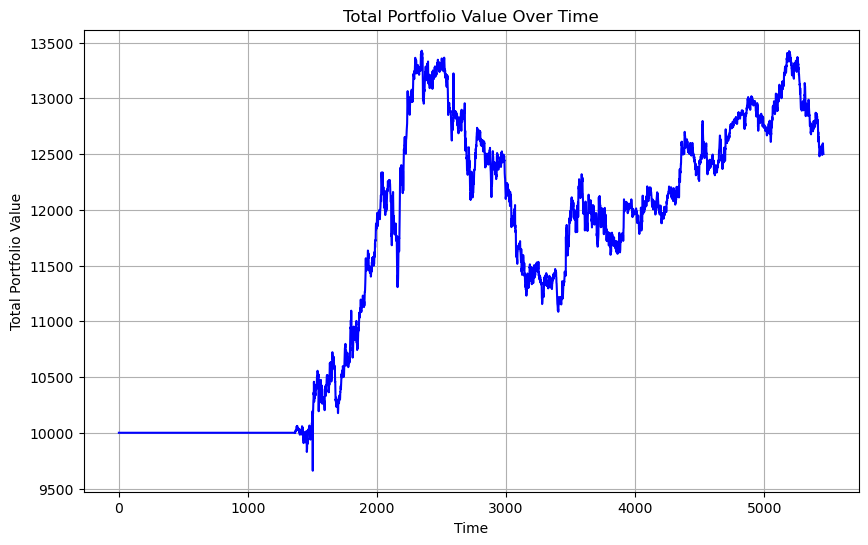

(2500.3812000000034, 10, 250.03812000000033)

In [24]:
pair_trading_strategy("dataset/VOO_1min_sample.csv","dataset/SPY_1min_sample.csv")

          Action  VOO_Shares  SPY_Shares      Cash     P/L
Timestamp                                                 
0           Hold         0.0         0.0  10000.00    0.00
1           Hold         0.0         0.0  10000.00    0.00
2           Hold         0.0         0.0  10000.00    0.00
3           Hold         0.0         0.0  10000.00    0.00
4           Hold         0.0         0.0  10000.00    0.00
...          ...         ...         ...       ...     ...
1396        Hold         0.0         0.0   9895.34  524.65
1397        Hold         0.0         0.0   9895.34  529.39
1398        Hold         0.0         0.0   9895.34  529.52
1399        Hold         0.0         0.0   9895.34  524.59
1400        Hold         0.0         0.0   9895.34  527.89

[1401 rows x 5 columns]
Total Profit: 527.89
Total Trades Executed: 3
Average Profit per Trade: 175.96


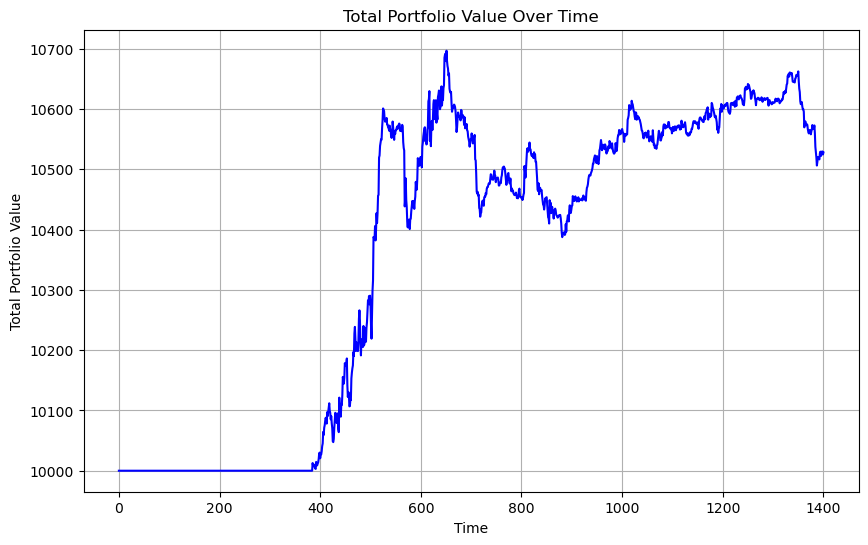

(527.8899999999921, 3, 175.96333333333072)

In [17]:
pair_trading_strategy("dataset/VOO_5min_sample.csv","dataset/SPY_5min_sample.csv")

          Action  VOO_Shares  SPY_Shares      Cash      P/L
Timestamp                                                  
0           Hold         0.0         0.0  10000.00    0.000
1           Hold         0.0         0.0  10000.00    0.000
2           Hold         0.0         0.0  10000.00    0.000
3           Hold         0.0         0.0  10000.00    0.000
4           Hold         0.0         0.0  10000.00    0.000
...          ...         ...         ...       ...      ...
297         Hold         0.0         0.0  10151.96  381.440
298         Hold         0.0         0.0  10151.96  429.120
299         Hold         0.0         0.0  10151.96  405.360
300         Hold         0.0         0.0  10151.96  403.808
301         Hold         0.0         0.0  10151.96  378.160

[302 rows x 5 columns]
Total Profit: 378.16
Total Trades Executed: 4
Average Profit per Trade: 94.54


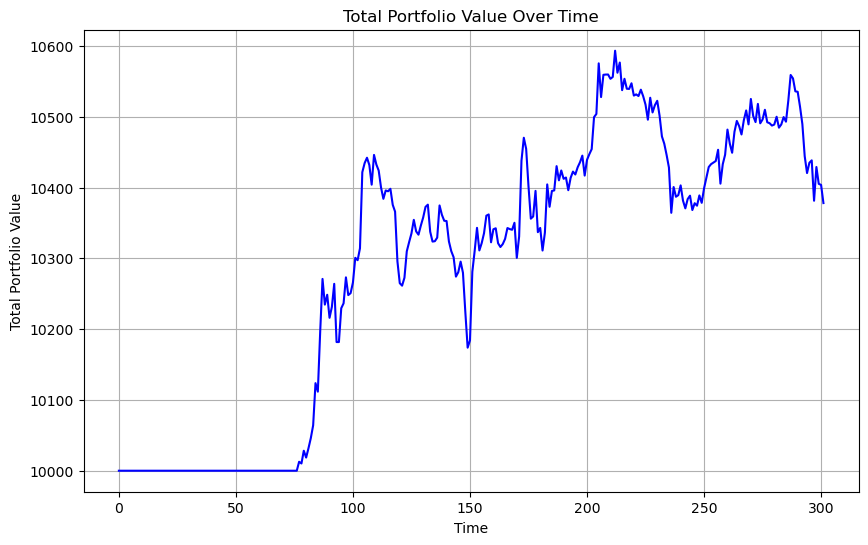

(378.15999999999985, 4, 94.53999999999996)

In [23]:
pair_trading_strategy("dataset/VOO_30min_sample.csv","dataset/SPY_30min_sample.csv")

          Action  VOO_Shares  SPY_Shares       Cash      P/L
Timestamp                                                   
0           Hold         0.0         0.0  10000.000    0.000
1           Hold         0.0         0.0  10000.000    0.000
2           Hold         0.0         0.0  10000.000    0.000
3           Hold         0.0         0.0  10000.000    0.000
4           Hold         0.0         0.0  10000.000    0.000
...          ...         ...         ...        ...      ...
159         Hold         0.0         0.0  10459.898  459.898
160         Hold         0.0         0.0  10459.898  459.898
161         Hold         0.0         0.0  10459.898  459.898
162         Hold         0.0         0.0  10459.898  459.898
163         Hold         0.0         0.0  10459.898  459.898

[164 rows x 5 columns]
Total Profit: 459.90
Total Trades Executed: 6
Average Profit per Trade: 76.65


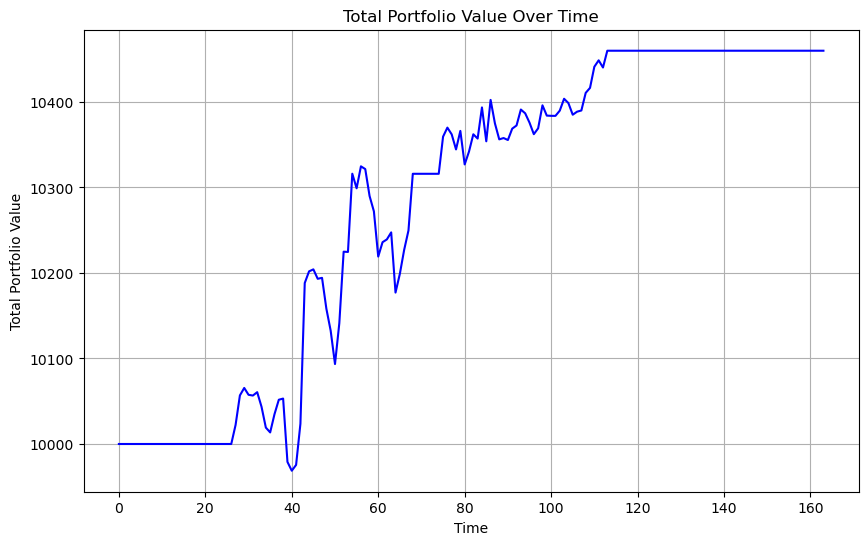

(459.89799999999923, 6, 76.64966666666653)

In [25]:
pair_trading_strategy("dataset/VOO_1hour_sample.csv","dataset/SPY_1hour_sample.csv")

In [ ]:
### GLD VS. IAU

          Action  VOO_Shares  SPY_Shares        Cash       P/L
Timestamp                                                     
0           Hold         0.0         0.0  10000.0000    0.0000
1           Hold         0.0         0.0  10000.0000    0.0000
2           Hold         0.0         0.0  10000.0000    0.0000
3           Hold         0.0         0.0  10000.0000    0.0000
4           Hold         0.0         0.0  10000.0000    0.0000
...          ...         ...         ...         ...       ...
4606        Hold         0.0         0.0  10396.7411  799.9811
4607        Hold         0.0         0.0  10396.7411  815.0111
4608        Hold         0.0         0.0  10396.7411  807.1311
4609        Hold         0.0         0.0  10396.7411  807.1311
4610        Hold         0.0         0.0  10396.7411  842.1411

[4611 rows x 5 columns]
Total Profit: 842.14
Total Trades Executed: 11
Average Profit per Trade: 76.56


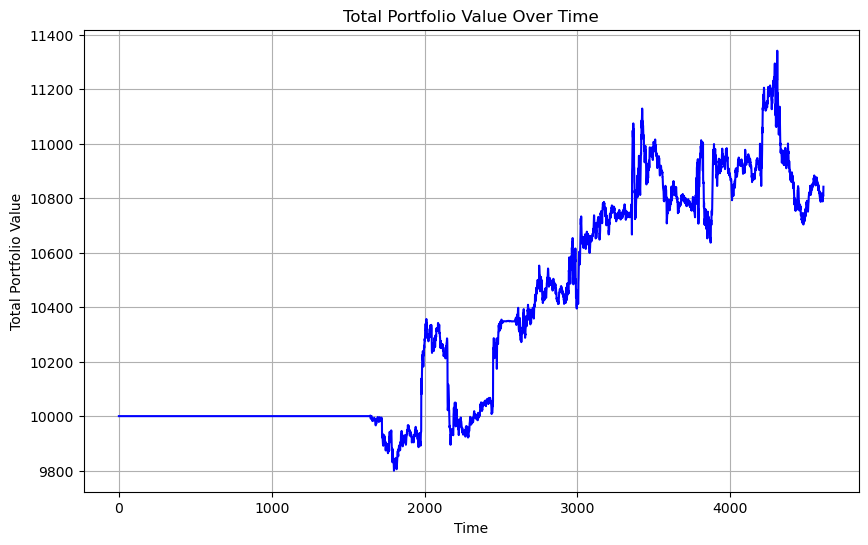

(842.1410999999935, 11, 76.55828181818123)

In [26]:
pair_trading_strategy("dataset/GLD_1min_sample.csv","dataset/IAU_1min_sample.csv")

          Action  VOO_Shares  SPY_Shares       Cash       P/L
Timestamp                                                    
0           Hold         0.0         0.0  10000.000    0.0000
1           Hold         0.0         0.0  10000.000    0.0000
2           Hold         0.0         0.0  10000.000    0.0000
3           Hold         0.0         0.0  10000.000    0.0000
4           Hold         0.0         0.0  10000.000    0.0000
...          ...         ...         ...        ...       ...
1135        Hold         0.0         0.0  10083.133  270.3030
1136        Hold         0.0         0.0  10083.133  271.3179
1137        Hold         0.0         0.0  10083.133  275.2500
1138        Hold         0.0         0.0  10083.133  274.8930
1139        Hold         0.0         0.0  10083.133  274.3830

[1140 rows x 5 columns]
Total Profit: 274.38
Total Trades Executed: 5
Average Profit per Trade: 54.88


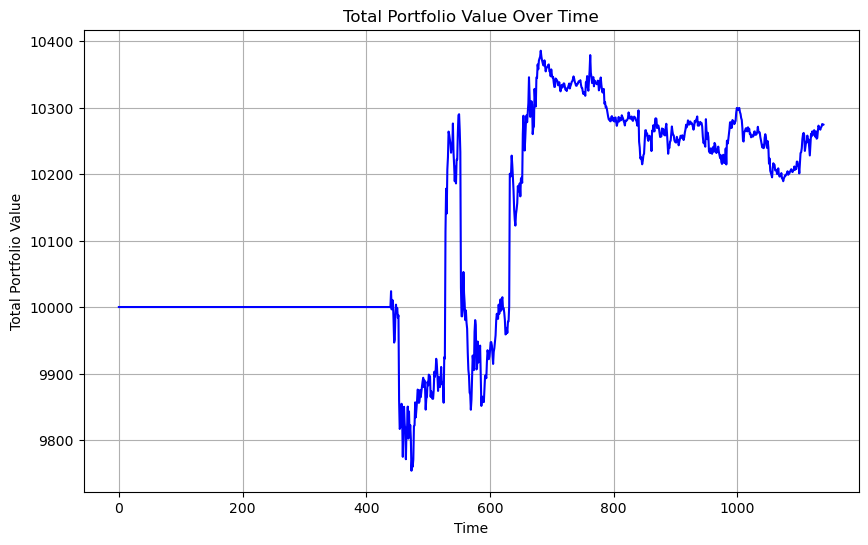

(274.382999999998, 5, 54.8765999999996)

In [27]:
pair_trading_strategy("dataset/GLD_5min_sample.csv","dataset/IAU_5min_sample.csv")

          Action  VOO_Shares  SPY_Shares       Cash       P/L
Timestamp                                                    
0           Hold         0.0         0.0  10000.000    0.0000
1           Hold         0.0         0.0  10000.000    0.0000
2           Hold         0.0         0.0  10000.000    0.0000
3           Hold         0.0         0.0  10000.000    0.0000
4           Hold         0.0         0.0  10000.000    0.0000
...          ...         ...         ...        ...       ...
265         Hold         0.0         0.0   9710.055  180.3602
266         Hold         0.0         0.0   9710.055  192.7562
267         Hold         0.0         0.0   9710.055  209.0150
268         Hold         0.0         0.0   9710.055  284.4950
269         Hold         0.0         0.0   9710.055  280.5350

[270 rows x 5 columns]
Total Profit: 280.54
Total Trades Executed: 6
Average Profit per Trade: 46.76


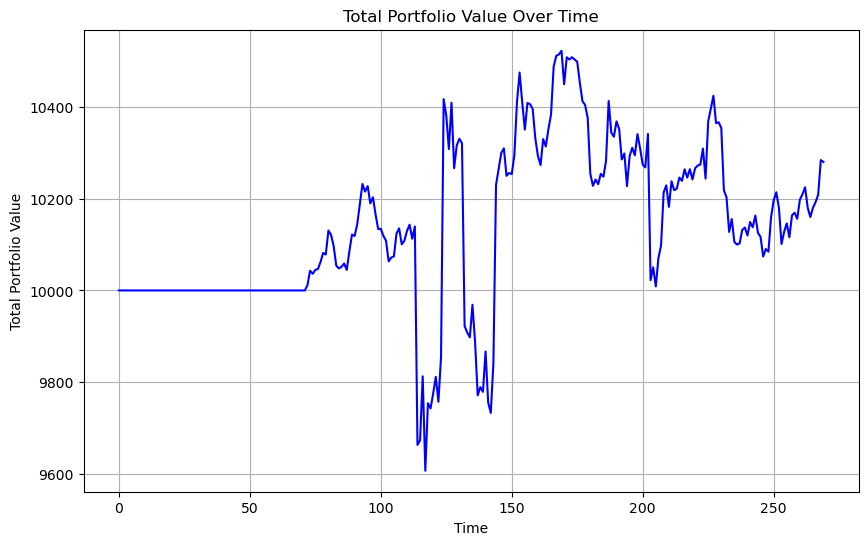

(280.5350000000035, 6, 46.75583333333392)

In [28]:
pair_trading_strategy("dataset/GLD_30min_sample.csv","dataset/IAU_30min_sample.csv")

                         Action  VOO_Shares  SPY_Shares       Cash      P/L
Timestamp                                                                  
0                          Hold         0.0         0.0  10000.000    0.000
1                          Hold         0.0         0.0  10000.000    0.000
2                          Hold         0.0         0.0  10000.000    0.000
3                          Hold         0.0         0.0  10000.000    0.000
4                          Hold         0.0         0.0  10000.000    0.000
...                         ...         ...         ...        ...      ...
144                        Hold         0.0         0.0   9707.638  291.338
145                        Hold         0.0         0.0   9707.638  269.198
146                        Hold         0.0         0.0   9707.638  266.118
147                        Hold         0.0         0.0   9707.638  284.478
148        Long VOO & Short SPY        52.0      -254.0   9704.118  333.458

[149 rows x

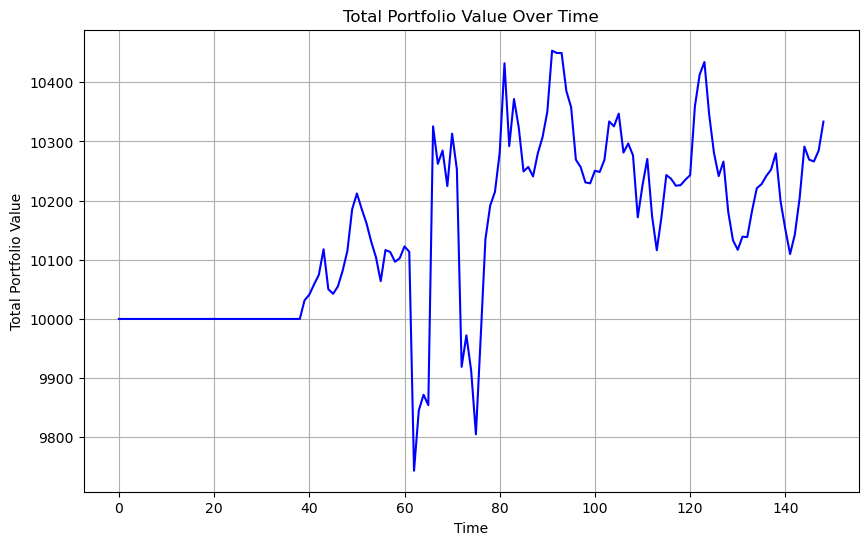

(333.4579999999969, 6, 55.57633333333282)

In [29]:
pair_trading_strategy("dataset/GLD_1hour_sample.csv","dataset/IAU_1hour_sample.csv")

In [30]:
pair_trading_strategy("dataset/spy_data.csv","dataset/voo_data.csv")

KeyError: 'close'